In [57]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats

# credit: https://www.pythoncharts.com/matplotlib/beautiful-bar-charts-matplotlib/


#### Global plotting style

In [58]:
# ---------------------------------
# High-resolution notebook display
# ---------------------------------
set_matplotlib_formats('retina')

# ---------------------------------
# Global plotting style
# ---------------------------------

# Optional: rebuild font cache once if needed
# mpl.font_manager._rebuild()

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 8,

    # Figure
    "figure.figsize": (8, 5),
    "figure.dpi": 120,

    # Axes
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,

    "axes.edgecolor": "#DDDDDD",
    "axes.labelcolor": "#333333",
    "axes.titleweight": "bold",
    "axes.titlesize": 11,
    "axes.labelsize": 10,

    # Grid
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#EEEEEE",
    "grid.linestyle": "-",
    "grid.linewidth": 1.0,

    # Ticks
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "xtick.major.size": 0,
    "ytick.major.size": 0,
})


#### Data prep

In [59]:
# ---------------------------------
# Load CSV
# ---------------------------------
df = pd.read_csv("data/incl_data/All studies.csv")

# ---------------------------------
# Clean column names
# ---------------------------------
df.columns = (
    df.columns
    .str.replace(r'[\n\r\t]+', '', regex=True)
    .str.strip()
)

# ---------------------------------
# Clean Year column
# ---------------------------------
df["Year"] = (
    df["Year"]
    .astype(str)
    .str.replace(r'[\n\r\t ]+', '', regex=True)
)

df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

# Keep valid years
df = df[df["Year"].between(2022, 2026)]


##### Annual publication distribution across included studies (2022--2026).

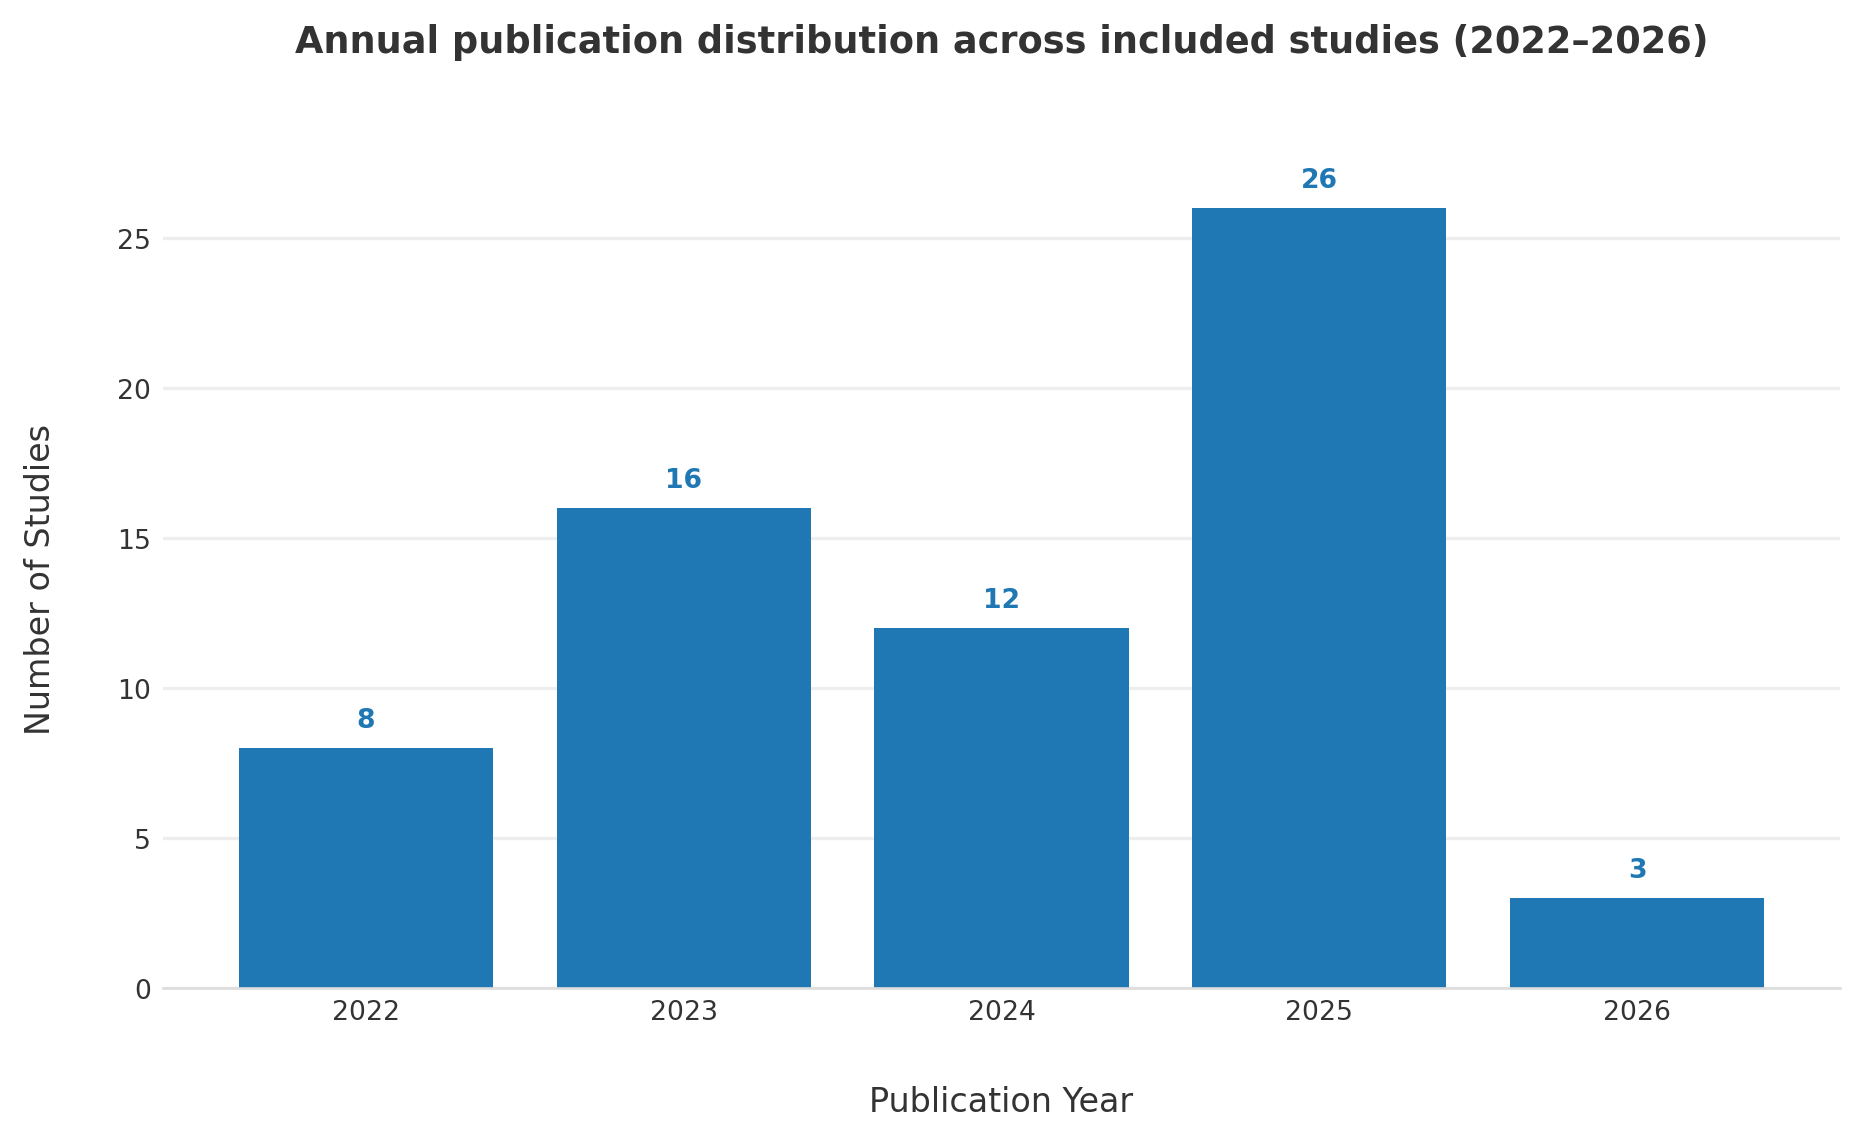

In [60]:
# ---------------------------------
# Count publications per year
# ---------------------------------
year_counts = (
    df["Year"]
    .value_counts()
    .sort_index()
)

# ---------------------------------
# Create figure
# ---------------------------------
fig, ax = plt.subplots()

bars = ax.bar(
    x=np.arange(len(year_counts)),
    height=year_counts.values,
    tick_label=year_counts.index.astype(str)
)

# ---------------------------------
# Axis formatting
# ---------------------------------
ax.spines['bottom'].set_color('#DDDDDD')

ax.tick_params(
    bottom=False,
    left=False
)

ax.yaxis.grid(True, color='#EEEEEE')
ax.xaxis.grid(False)

# ---------------------------------
# Labels and title
# ---------------------------------
ax.set_xlabel(
    "Publication Year",
    labelpad=18,
    color='#333333'
)

ax.set_ylabel(
    "Number of Studies",
    labelpad=18,
    color='#333333'
)

ax.set_title(
    "Annual publication distribution across included studies (2022–2026)",
    pad=35,
    color='#333333',
    weight='bold'
)

# ---------------------------------
# Add value labels above bars
# ---------------------------------
bar_color = bars[0].get_facecolor()

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        int(bar.get_height()),
        ha='center',
        va='bottom',
        color=bar_color,
        weight='bold'
    )

# ---------------------------------
# Layout
# ---------------------------------
fig.tight_layout(pad=2)

# ---------------------------------
# Create output directory
# ---------------------------------
Path("data/figures/litRES").mkdir(
    parents=True,
    exist_ok=True
)

# ---------------------------------
# Save figure
# ---------------------------------
plt.savefig(
    "data/figures/litRES/annual_publication_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Accelerometer         10
Gyroscope              6
Magnetometer           2
Heart-rate sensor      3
Temperature sensor     1
GPS                    3
SpO2 sensor            1
dtype: int64


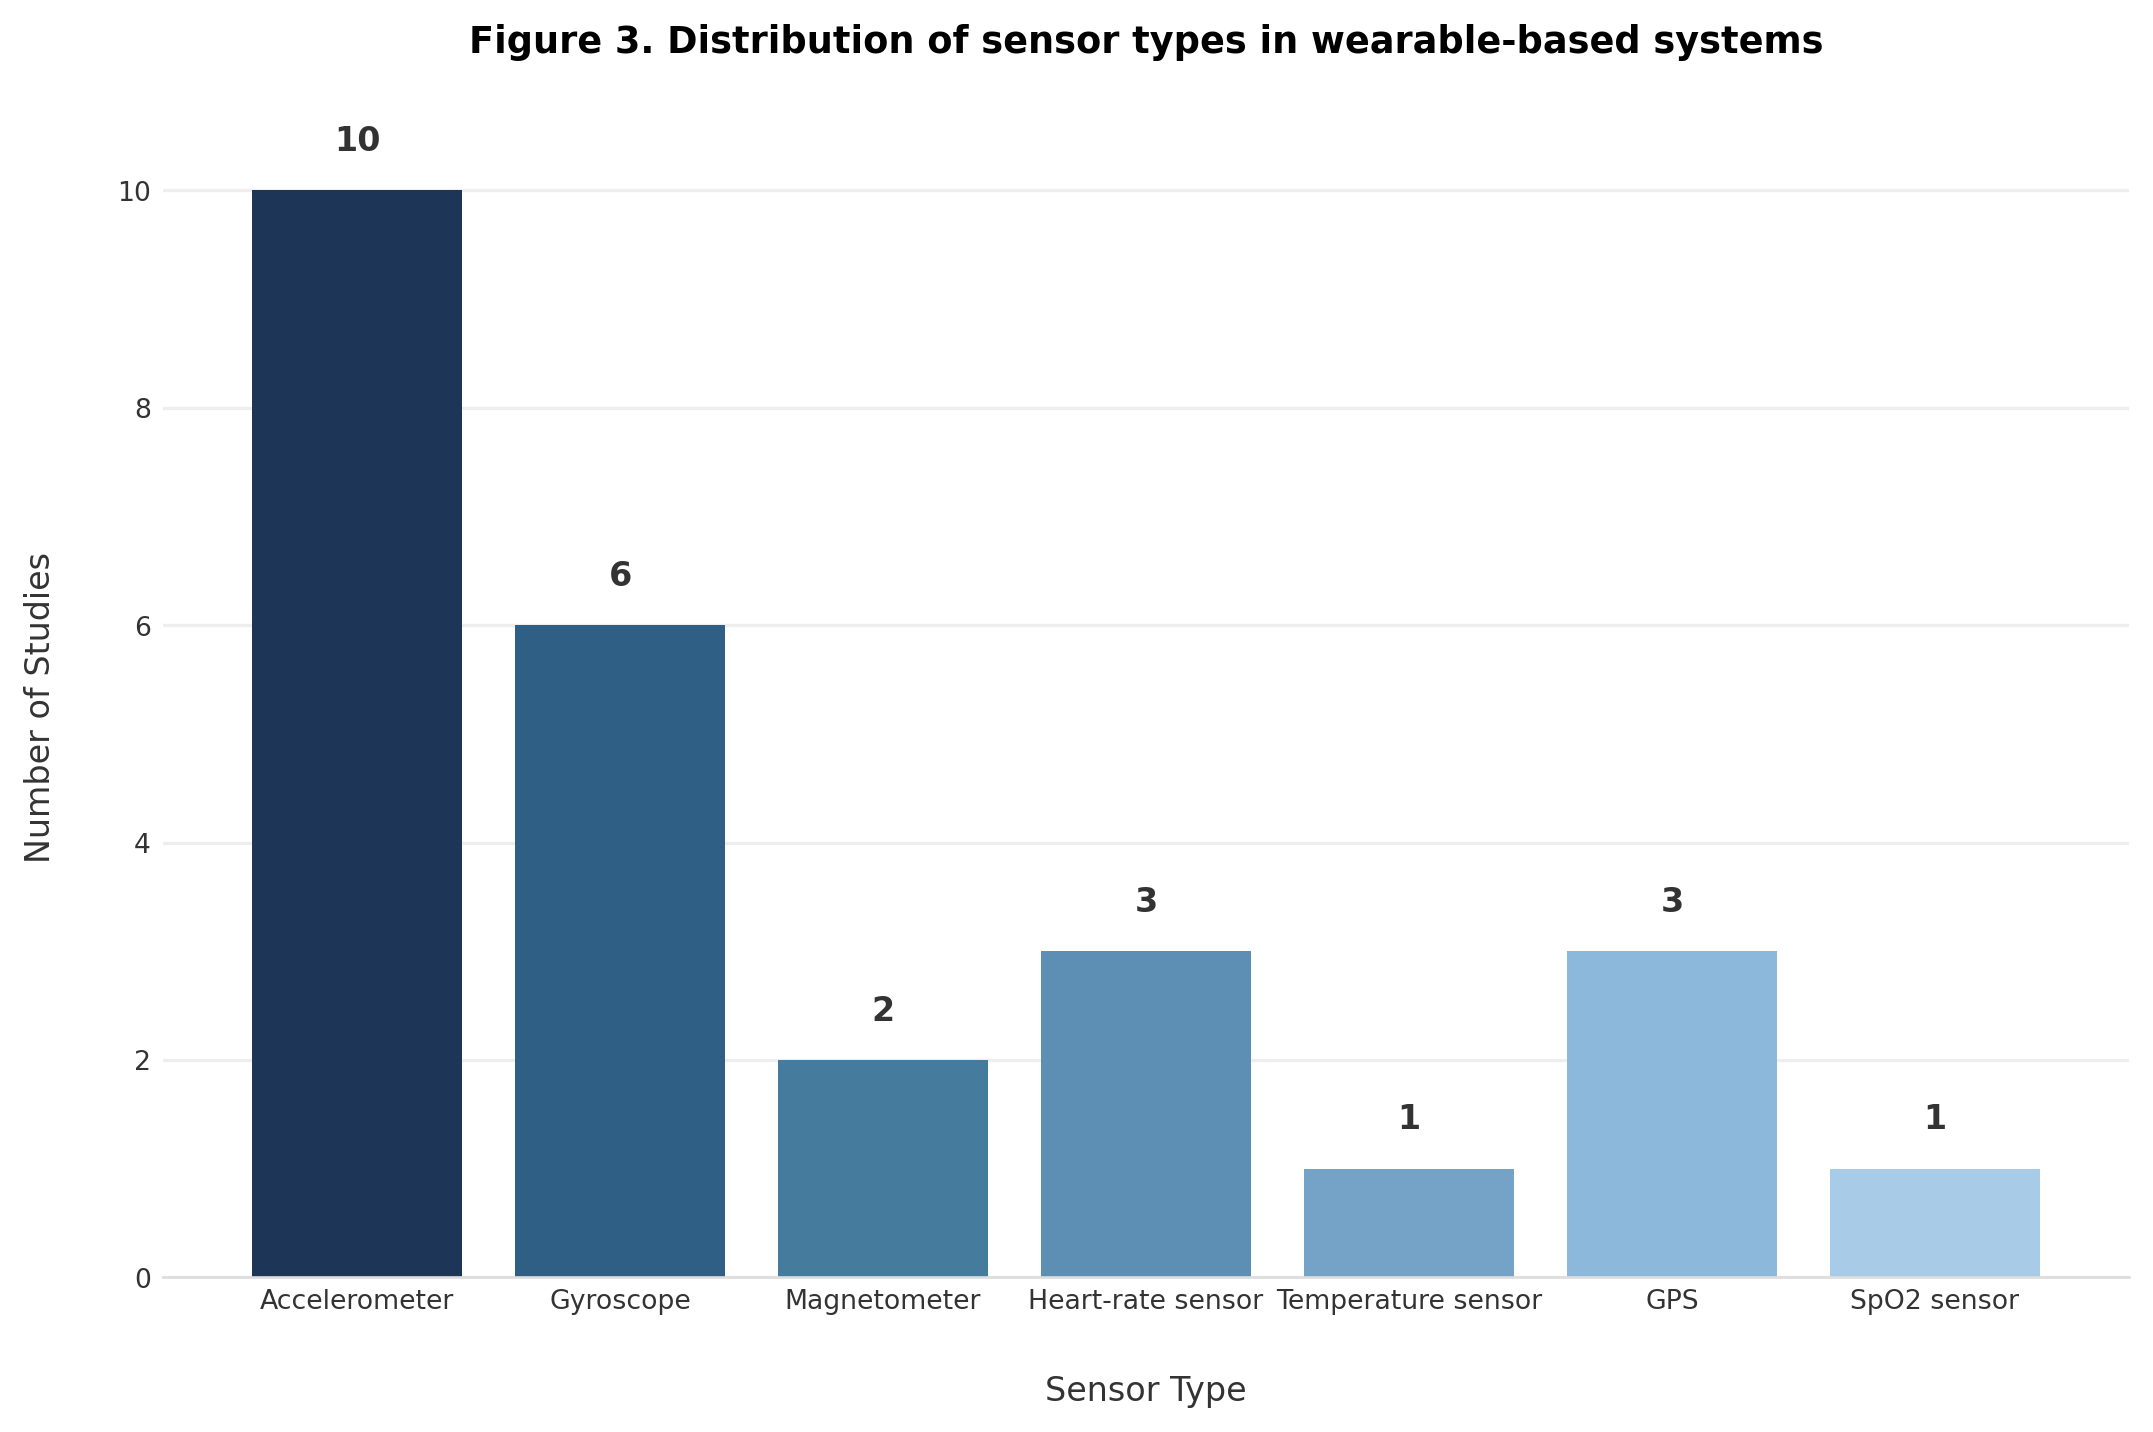

In [61]:
from collections import Counter
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

# ---------------------------------
# Keep only wearable-based studies
# ---------------------------------
wearable_df = df[df["Sensor modality"] == "Wearable"].copy()

# ---------------------------------
# Column containing sensor info
# ---------------------------------
sensor_col = "Sensor type"

# ---------------------------------
# Clean text
# ---------------------------------
wearable_df[sensor_col] = (
    wearable_df[sensor_col]
    .astype(str)
    .str.replace(r'[\n\r\t]+', ' ', regex=True)
    .str.strip()
)

# ---------------------------------
# Extract and count sensors
# ---------------------------------
all_sensors = []

for item in wearable_df[sensor_col]:

    # Split multiple sensors in same cell
    parts = re.split(r'[,;/]', item)

    for p in parts:
        p = p.strip()

        if p:
            all_sensors.append(p)

# ---------------------------------
# Count occurrences
# ---------------------------------
sensor_counts = pd.Series(Counter(all_sensors))

# Desired order
sensor_order = [
    "Accelerometer",
    "Gyroscope",
    "Magnetometer",
    "Heart-rate sensor",
    "Temperature sensor",
    "GPS",
    "SpO2 sensor"
]

sensor_counts = sensor_counts.reindex(sensor_order).fillna(0)

print(sensor_counts)

# ---------------------------------
# Gradient color palette
# ---------------------------------
colors = [
    "#1d3557",
    "#2f5f85",
    "#457b9d",
    "#5c8fb3",
    "#74a3c7",
    "#8cb8db",
    "#a8cbe8"
]

# ---------------------------------
# Create figure
# ---------------------------------
fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(
    sensor_counts.index,
    sensor_counts.values,
    color=colors
)

# ---------------------------------
# Axis formatting
# ---------------------------------
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['bottom'].set_color('#DDDDDD')
ax.spines['left'].set_color('#DDDDDD')

ax.tick_params(
    bottom=False,
    left=False
)

ax.yaxis.grid(True, color="#EEEEEE")
ax.xaxis.grid(False)

# ---------------------------------
# Labels and title
# ---------------------------------
ax.set_xlabel(
    "Sensor Type",
    labelpad=18
)

ax.set_ylabel(
    "Number of Studies",
    labelpad=18
)

ax.set_title(
    "Figure 3. Distribution of sensor types in wearable-based systems",
    pad=25
)

# ---------------------------------
# Add labels above bars
# ---------------------------------
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        int(bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        weight='bold',
        color='#333333'
    )

# ---------------------------------
# Layout
# ---------------------------------
fig.tight_layout()

# ---------------------------------
# Save figure
# ---------------------------------
Path("data/figures/litRES").mkdir(
    parents=True,
    exist_ok=True
)

plt.savefig(
    "data/figures/litRES/sensor_distribution_wearable.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

mmWave/FMCW radar             24
Acoustic                       2
Wi-Fi CSI                      7
UWB radar                      2
Vibration/Pressure sensing     4
Passive Wi-Fi radar            2
Electrostatic sensor           1
Infrared (IR)                  1
dtype: int64


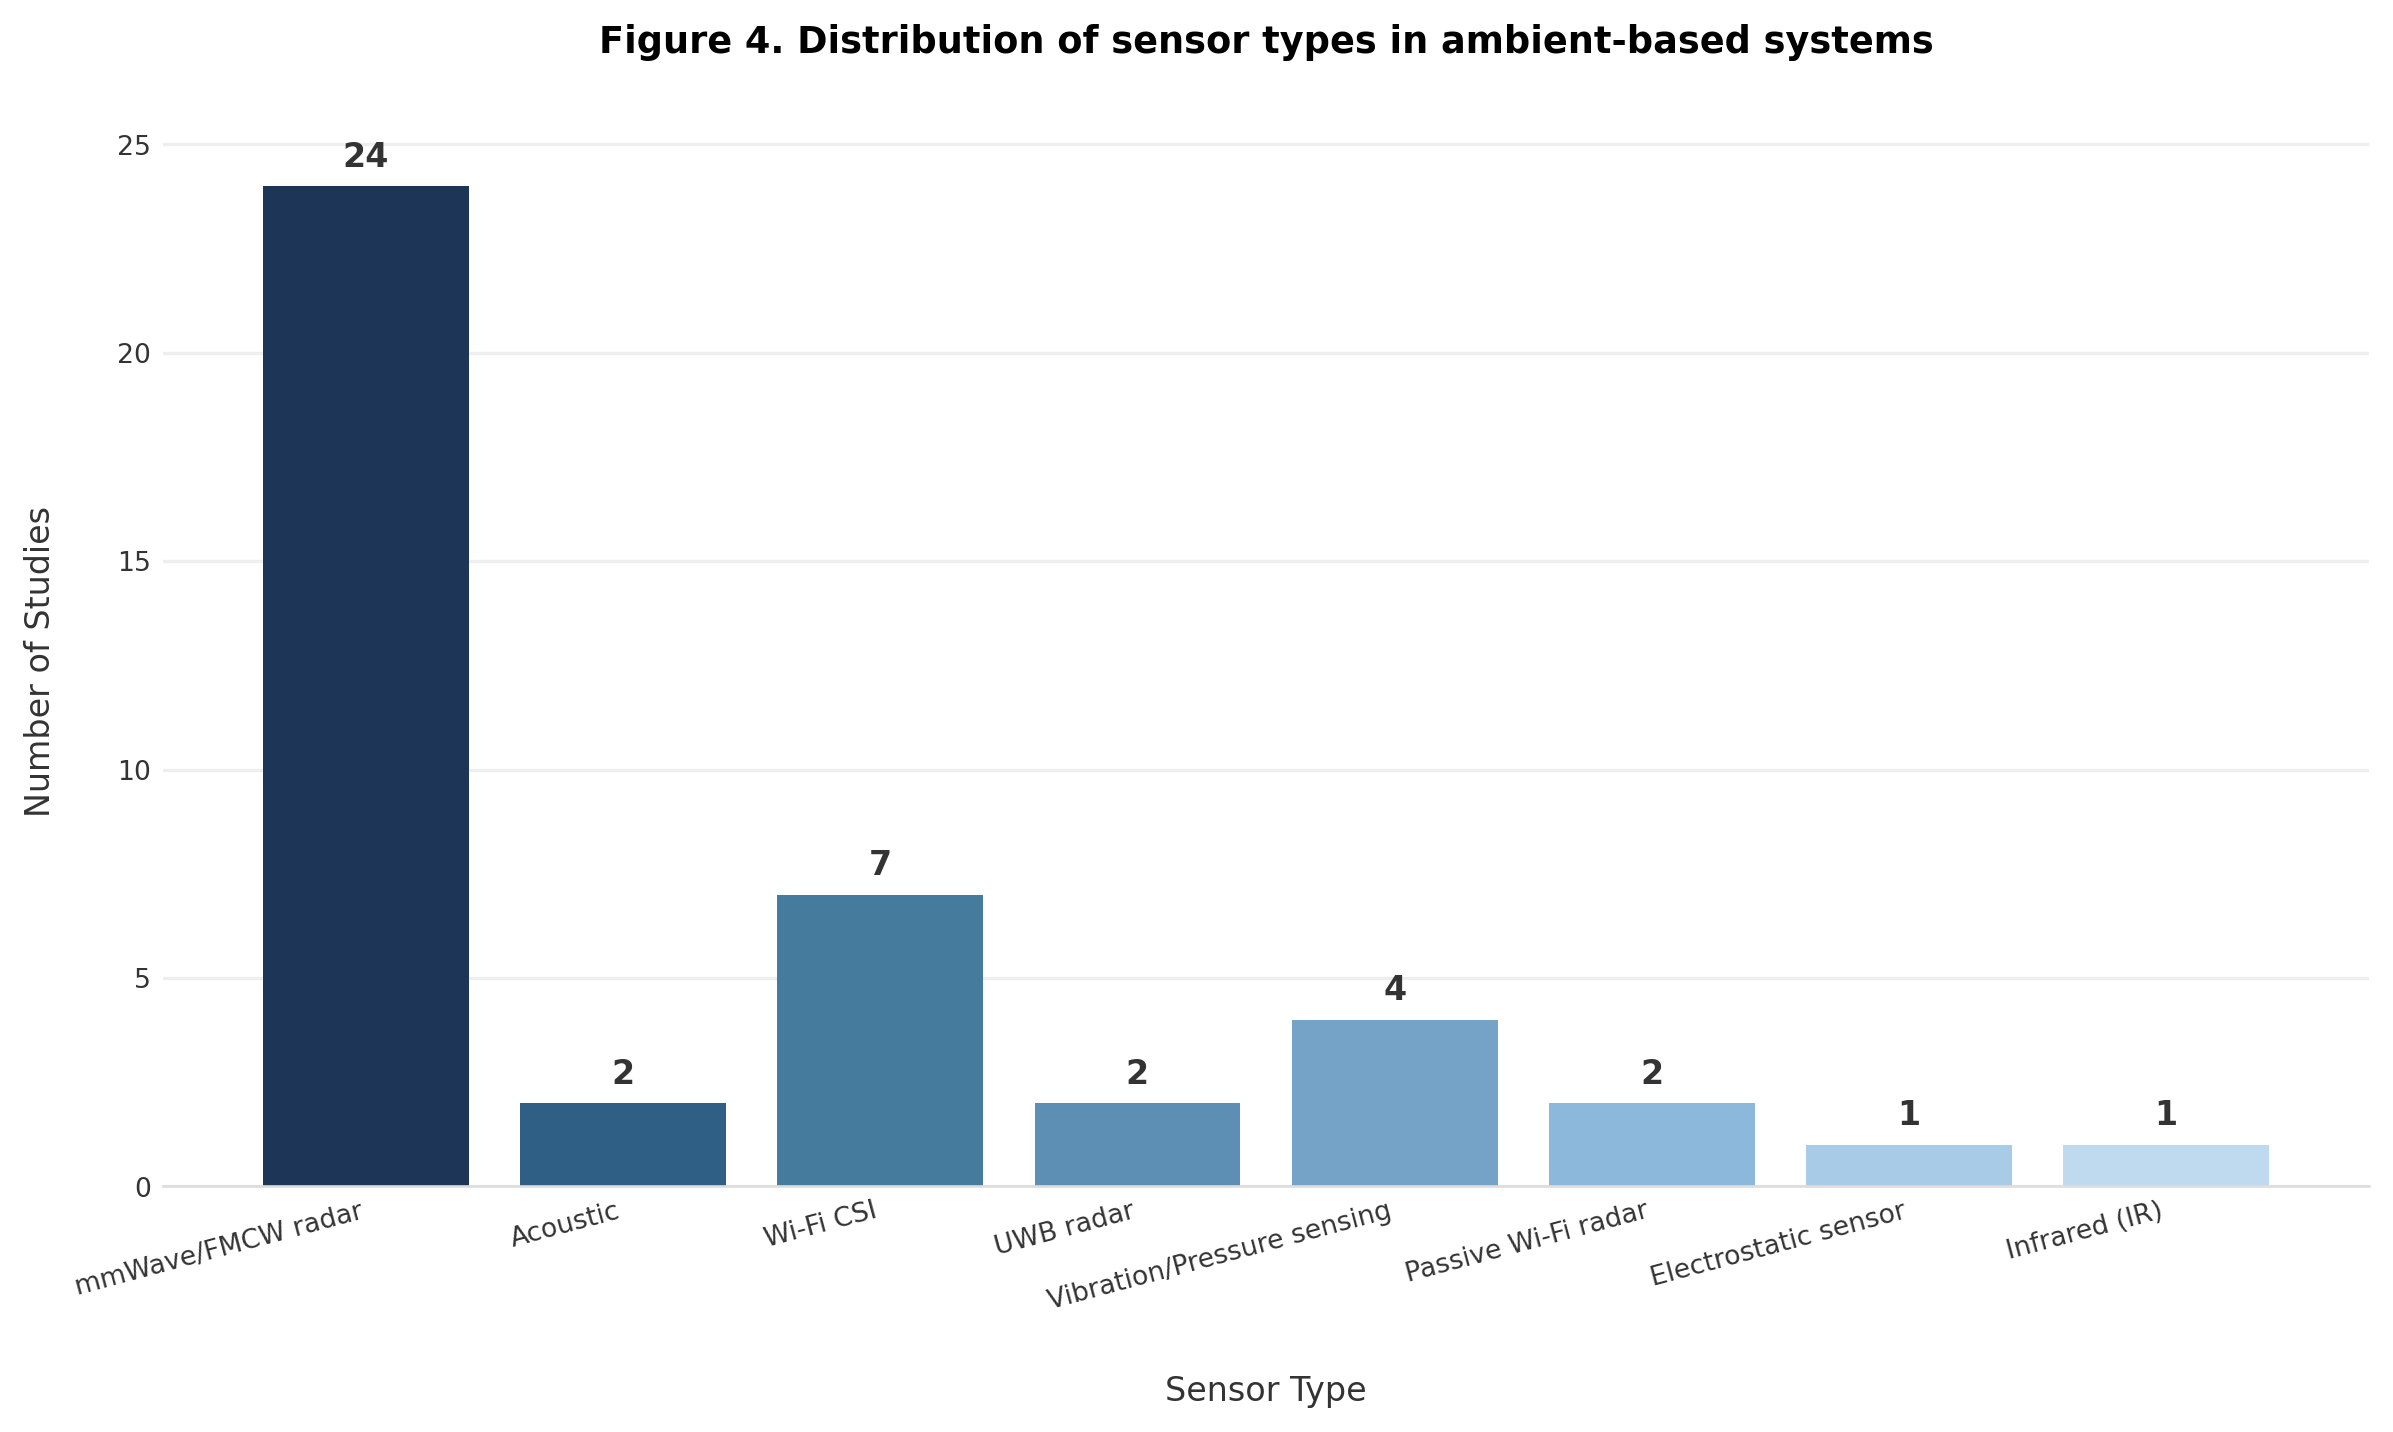

In [62]:
from collections import Counter
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

# ---------------------------------
# Keep only ambient-based studies
# ---------------------------------
ambient_df = df[df["Sensor modality"] == "Ambient"].copy()

# ---------------------------------
# Column containing sensor info
# ---------------------------------
sensor_col = "Sensor type"

# ---------------------------------
# Clean text
# ---------------------------------
ambient_df[sensor_col] = (
    ambient_df[sensor_col]
    .astype(str)
    .str.replace(r'[\n\r\t]+', ' ', regex=True)
    .str.strip()
)

# ---------------------------------
# Extract and count sensors
# ---------------------------------
all_sensors = []

for item in ambient_df[sensor_col]:

    # Split multiple sensors in same cell
    parts = re.split(r'[,;/]', item)

    for p in parts:

        p = p.strip()

        # ---------------------------------
        # Merge split labels correctly
        # ---------------------------------
        if p in ["mmWave", "FMCW radar", "FMCW millimeter-wave radar"]:
            all_sensors.append("mmWave/FMCW radar")

        elif (
            p == "Vibration"
            or p == "Pressure sensing"
            or "vibration" in p.lower()
            or "pressure" in p.lower()
        ):
            all_sensors.append("Vibration/Pressure sensing")

        elif p:
            all_sensors.append(p)

# ---------------------------------
# Count occurrences
# ---------------------------------
sensor_counts = pd.Series(Counter(all_sensors))

# ---------------------------------
# Combine counts manually
# ---------------------------------
sensor_counts_final = pd.Series({
    "mmWave/FMCW radar":
        sensor_counts.get("mmWave/FMCW radar", 0),

    "Acoustic":
        sensor_counts.get("Acoustic", 0),

    "Wi-Fi CSI":
        sensor_counts.get("Wi-Fi CSI", 0),

    "UWB radar":
        sensor_counts.get("UWB radar", 0),

    "Vibration/Pressure sensing":
        sensor_counts.get("Vibration/Pressure sensing", 0),

    "Passive Wi-Fi radar":
        sensor_counts.get("Passive Wi-Fi radar", 0),

    "Electrostatic sensor":
        sensor_counts.get("Electrostatic sensor", 0),

    "Infrared (IR)":
        sensor_counts.get("Infrared (IR)", 0)
})

print(sensor_counts_final)

# ---------------------------------
# Gradient color palette
# ---------------------------------
colors = [
    "#1d3557",
    "#2f5f85",
    "#457b9d",
    "#5c8fb3",
    "#74a3c7",
    "#8cb8db",
    "#a8cbe8",
    "#bfd9ef"
]

# ---------------------------------
# Create figure
# ---------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    sensor_counts_final.index,
    sensor_counts_final.values,
    color=colors
)

# ---------------------------------
# Axis formatting
# ---------------------------------
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['bottom'].set_color('#DDDDDD')
ax.spines['left'].set_color('#DDDDDD')

ax.tick_params(
    bottom=False,
    left=False
)

ax.yaxis.grid(True, color="#EEEEEE")
ax.xaxis.grid(False)

plt.xticks(rotation=15, ha='right')

# ---------------------------------
# Labels and title
# ---------------------------------
ax.set_xlabel(
    "Sensor Type",
    labelpad=18
)

ax.set_ylabel(
    "Number of Studies",
    labelpad=18
)

ax.set_title(
    "Figure 4. Distribution of sensor types in ambient-based systems",
    pad=25
)

# ---------------------------------
# Add labels above bars
# ---------------------------------
for bar in bars:

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        int(bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        weight='bold',
        color='#333333'
    )

# ---------------------------------
# Layout
# ---------------------------------
fig.tight_layout()

# ---------------------------------
# Save figure
# ---------------------------------
Path("data/figures/litRES").mkdir(
    parents=True,
    exist_ok=True
)

plt.savefig(
    "data/figures/litRES/sensor_distribution_ambient.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()